In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
iris_df=sns.load_dataset("iris")
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
X = iris_df.drop(['species'], axis=1)

# creating label set
y = iris_df["species"]

# converting labels to numbers
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
y = le.fit_transform(y)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [5]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [6]:
from sklearn.decomposition import PCA

# creating object of the PCA class
pca = PCA()

# training PCA model on training data
X_train = pca.fit_transform(X_train)

# making predictions on test data
X_test = pca.transform(X_test)

In [7]:
variance_ratios = pca.explained_variance_ratio_
print(variance_ratios)

[0.72229951 0.2397406  0.03335483 0.00460506]


In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression

# training the logistic regression model
lg = LogisticRegression()
lg.fit(X_train, y_train)

# Predicting the Test set results
y_pred = lg.predict(X_test)

# evaluating results
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.8666666666666667


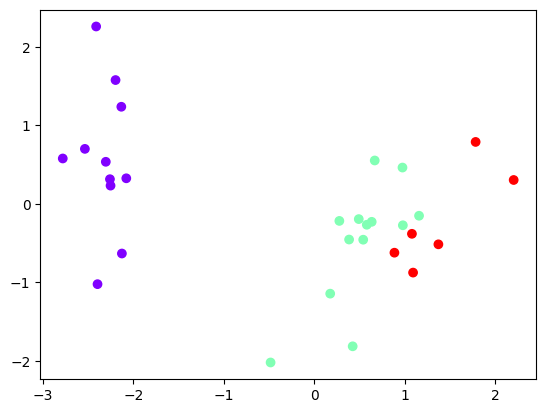

In [10]:
from matplotlib import pyplot as plt
%matplotlib inline

# print actual datapoints
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='rainbow')
plt.show()

#LDA

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
banknote_df = pd.read_csv("/content/banknote.csv")
banknote_df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [15]:
X = banknote_df.drop(["class"], axis=1)  # All columns except 'class'
y = banknote_df["class"]

In [16]:
from sklearn.model_selection import train_test_split

# Assuming X and y are already defined
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [17]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
sc = StandardScaler()

# Fit and transform the training set
X_train = sc.fit_transform(X_train)

# Transform the test set using the same scaler
X_test = sc.transform(X_test)

In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Creating an object of the LDA class
lda = LDA()

# Training the LDA model on the training data
X_train = lda.fit_transform(X_train, y_train)

# Making predictions on the test data
X_test = lda.transform(X_test)

In [19]:
variance_ratios = lda.explained_variance_ratio_

# Print the explained variance ratios
print(variance_ratios)

[1.]


In [20]:
lda = LDA(n_components=1)

# Training the LDA model on the training data and transforming it
X_train = lda.fit_transform(X_train, y_train)

# Transforming the test data using the trained LDA model
X_test = lda.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Training the Logistic Regression model
lg = LogisticRegression()
lg.fit(X_train, y_train)

# Predicting the Test set results
y_pred = lg.predict(X_test)

# Evaluating results by calculating accuracy
print(accuracy_score(y_test, y_pred))

0.9890909090909091


Project - PCA

In [25]:
data = pd.read_csv('/content/customer_churn.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [26]:
X = data.drop(['RowNumber','CustomerId','Surname'], axis=1)

y = data["Exited"]


In [30]:
X.dtypes

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


In [32]:
numerical = X.drop(['Geography', 'Gender'],axis=1)
categorical = X[['Geography', 'Gender']]

In [33]:
cat_numerical = pd.get_dummies(categorical,drop_first=True)
cat_numerical.head()

,Geography_Germany,Geography_Spain,Gender_Male
0,False,False,False
1,False,True,False
2,False,False,False
3,False,False,False
4,False,True,False


In [34]:
X = pd.concat([numerical, cat_numerical], axis = 1)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [36]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [37]:
from sklearn.decomposition import PCA

# creating object of the PCA class
pca = PCA()

# training PCA model on training data
X_train = pca.fit_transform(X_train)

# making predictions on test data
X_test = pca.transform(X_test)

In [38]:
variance_ratios = pca.explained_variance_ratio_
print(variance_ratios)

[0.14558576 0.1043621  0.0942598  0.0902122  0.08466387 0.0837737
 0.08280054 0.08111    0.07913871 0.06356104 0.05138349 0.03914879]


In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [40]:
from sklearn.linear_model import LogisticRegression

# training the logistic regression model
lg = LogisticRegression()
lg.fit(X_train, y_train)

# Predicting the Test set results
y_pred = lg.predict(X_test)

# evaluating results
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.9495
